In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt

import xobjects as xo
import xpart as xp
import xtrack as xt
import xdeps as xd

In [2]:
def matchSummary(opt):
    for tt in opt._err.targets:
        if tt.line:
           nn=" ".join((tt.line,)+tt.tar)
           rr=tt.action.run()[tt.line][tt.tar]
        else:
           nn=tt.tar
           nn=" ".join(nn)
           rr=tt.action.run()[tt.tar]
        if(type(tt.value)==xt.match.LessThan):
            vv=tt.value.upper
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}') 
        elif(type(tt.value)==xt.match.GreaterThan):
            vv=tt.value.lower
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
        elif(hasattr(tt,'rhs')):
            vv=tt.rhs
            dd=(rr-vv)
            if(tt.ineq_sign=='>'):
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
            else:
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}')   
        else:
            vv=tt.value
            dd=(rr-vv)
            dd=np.abs(dd)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {dd<tt.tol}')

In [3]:
class nonlin_chroma(xd.Action):
    def __init__(self, line):
        self.line = line

    def run(self):
        deg = 4

        delta_values = np.arange(-3e-3, 3e-3, 0.5e-3)

        qx_values = delta_values * 0
        qy_values = delta_values * 0
        for i, delta in enumerate(delta_values):
            tt = self.line.twiss4d(delta0=delta)

            qx_values[i] = tt.qx
            qy_values[i] = tt.qy

        
        qx_fit = np.polyfit(delta_values, qx_values, deg=deg, full=False, cov=True)
        qx_coeff = qx_fit[0]
        print("qx coeff:", qx_coeff)

        qy_fit = np.polyfit(delta_values, qy_values, deg=deg, full=False, cov=True)
        qy_coeff = qy_fit[0]
        print("qy coeff:", qy_coeff)

        return {'qx0': qx_coeff[4], 'qy0': qy_coeff[4], 
                'qx1': qx_coeff[3], 'qy1': qy_coeff[3], 
                'qx2': qx_coeff[2], 'qy2': qy_coeff[2], 
                'qx3': qx_coeff[1], 'qy3': qy_coeff[1], 
                'qx4': qx_coeff[0], 'qy4': qy_coeff[0], 
                # 'qx5': qx_coeff[2], 'qy5': qy_coeff[2], 
                # 'qx6': qx_coeff[1], 'qy6': qy_coeff[1], 
                # 'qx7': qx_coeff[0], 'qy7': qy_coeff[0], 
               }

In [4]:
def twiss_scan(line: xt.Line, delta_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    tw0 = line.twiss4d(delta0=0.0)
    rows: list[tuple[float, float, float]] = [(0.0, float(tw0.qx), float(tw0.qy))]

    co_prev = tw0.particle_on_co
    neg_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid < 0][::-1]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            neg_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            neg_rows.append((float(delta), np.nan, np.nan))

    co_prev = tw0.particle_on_co
    pos_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid > 0]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            pos_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            pos_rows.append((float(delta), np.nan, np.nan))

    rows = neg_rows[::-1] + rows + pos_rows
    d = np.array([r[0] for r in rows], dtype=float)
    qx = np.array([r[1] for r in rows], dtype=float)
    qy = np.array([r[2] for r in rows], dtype=float)
    return d, qx, qy

# Load fitting

In [5]:
line = xt.load('sps_with_aperture_inj_q20_beam_sagitta4.json')
env = line.env
tt = line.get_table()

tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

# env.extend_knl_ksl(order=9, element_names=list(mba)+list(mbb)+list(qf)+list(qd))
#Creating knobs for the non-linear chromaticity fit
env['b3_mba'] = 0
env['b3_mbb'] = 0
env['b4_qd'] = 0
env['b4_qf'] = 0
env['b5_mba'] = 0
env['b5_mbb'] = 0
env['b6_qd'] = 0
env['b6_qf'] = 0
# env['b7_mba'] = 0
# env['b7_mbb'] = 0
# env['b8_qd'] = 0
# env['b8_qf'] = 0
# env['b9_mba'] = 0
# env['b9_mbb'] = 0
#Defining deferred expressions for each dipole and quadrupole
#Dipoles get b3,b5
#Quadrupoles get b4,b6

tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

# env.vars["qph_setvalue"] = 0.0
# env.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env[nn].knl[2] = 'b3_mba'
    env[nn].knl[4] = 'b5_mba'
for nn in mbb:
    env[nn].knl[2] = 'b3_mbb'
    env[nn].knl[4] = 'b5_mbb'
for nn in qf:
    env[nn].knl[3] = 'b4_qf'
    env[nn].knl[5] = 'b6_qf'
for nn in qd:
    env[nn].knl[3] = 'b4_qd'
    env[nn].knl[5] = 'b6_qd'


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           


In [ ]:
with open("/Users/lisepauwels/phd/data/sps-measurements/results_chroma/analysis2/tune_fit_v2/tune_poly_coefficients.json") as f:
      coeffs = json.load(f)

qx_coeff = np.array(coeffs["Qx_kickH"]["poly4"]["coefficients_high_to_low"])
qy_coeff = np.array(coeffs["Qy_kickV"]["poly4"]["coefficients_high_to_low"])

qx0 = qx_coeff[4] + 20
qx1 = qx_coeff[3]
qx2 = qx_coeff[2]
qx3 = qx_coeff[1]
qx4 = qx_coeff[0]

qy0 = qy_coeff[4] + 20
qy1 = qy_coeff[3]
qy2 = qy_coeff[2]
qy3 = qy_coeff[1]
qy4 = qy_coeff[0]

print(qx0, qx1, qx2, qx3, qx4)
print(qy0, qy1, qy2, qy3, qy4)

20.135651385655766 1.3853870500626928 -485.37111311696805 -98753.84952493232 39044666.236123264
20.178849830100283 1.3404718005055556 -732.9755010775554 59867.04451836026 19608320.65383154


# Comparison with old error model

In [7]:
#Hannes error model for comparison step by step
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx0,       qy=qy0,       tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-2, tag="chrom"),
        ],
    )

delta_grid2 = np.linspace(-3e-3, 3e-3, 21)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 11.28                             
Matching: model call n. 15 penalty = 7.5300e-06              
Optimize - end penalty:  7.52996e-06                            


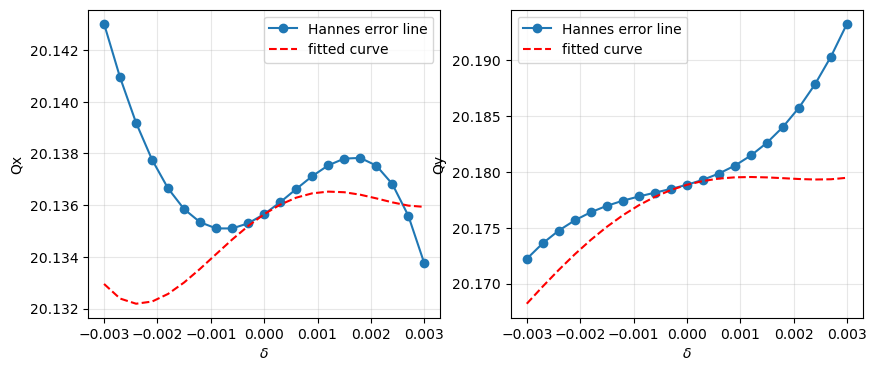

In [8]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)


axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4, 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel(r"$\delta$")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

# Optimisation 

In [9]:
line.vars["qph_setvalue"] = qx1/qx0#0.155
line.vars["qpv_setvalue"] = qy1/qy0#0.13

act_chroma = nonlin_chroma(line)

## Optimising tune

In [10]:
#Measured tunes at delta=0
opt_tune = line.match(
    vary=[
        xt.VaryList(['kqf', 'kqd'], step=1e-8), 
    ],
    targets=[
        xt.TargetSet(qx=qx0, qy=qy0, tol=1e-10),
    ])

                                             
Optimize - start penalty: 0.1888                            
Matching: model call n. 11 penalty = 5.4988e-11              
Optimize - end penalty:  5.49882e-11                            


In [11]:
print("Quadrupole strengths needed to recover measured tunes:")
print("kqf =", line.vars["kqf"]._get_value())
print("kqd =", line.vars["kqd"]._get_value())

Quadrupole strengths needed to recover measured tunes:
kqf = 0.011586759826608116
kqd = -0.01158663347678003


In [12]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [ 2.00678269e+03  2.43615647e+02 -1.97490011e+01  1.37293820e+00
  2.01356541e+01]
qy coeff: [-5.70847803e+03  8.01824064e+02 -8.42814183e+01  1.23308101e+00
  2.01788515e+01]
Q0:
targets  : 20.135651385655766 20.178849830100283
obtained : 20.135654090624147 20.178851458197183
Q1:
targets  : 1.3853870500626928 1.3404718005055556
obtained : 1.3729381980136435 1.2330810141991833
Q2:
targets  : -485.37111311696805 -732.9755010775554
obtained : -19.749001118903536 -84.28141831716898
Q3:
targets  : -98753.84952493232 59867.04451836026
obtained : 243.6156468821703 801.8240641467532
Q4:
targets  : 39044666.236123264 19608320.65383154
obtained : 2006.7826880035518 -5708.478027779678


## Optimising Q1

In [13]:
opt_q1 = line.match(
    vary=[
        xt.VaryList(['b3_mba', 'b3_mbb'], step=1e-7), 
    ],
    targets=[
        xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-7),
    ])

                                             
Optimize - start penalty: 0.1079                            
Matching: model call n. 85 penalty = 6.1432e-08              
Optimize - end penalty:  6.14319e-08                            


In [14]:
print("Sextupole errors on main dipoles needed to recover first order chromaticity:")
print("b3_mba =", line.vars["b3_mba"]._get_value())
print("b3_mbb =", line.vars["b3_mbb"]._get_value())

Sextupole errors on main dipoles needed to recover first order chromaticity:
b3_mba = 1.2953616912388827e-05
b3_mbb = -2.4479974566182746e-05


In [15]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [ 2.02557712e+03  2.42382730e+02 -1.97178254e+01  1.38531341e+00
  2.01356541e+01]
qy coeff: [-5.74596974e+03  8.05738207e+02 -8.46194265e+01  1.34024426e+00
  2.01788515e+01]
Q0:
targets  : 20.135651385655766 20.178849830100283
obtained : 20.135654096728537 20.178851535262226
Q1:
targets  : 1.3853870500626928 1.3404718005055556
obtained : 1.3853134095847288 1.34024426148669
Q2:
targets  : -485.37111311696805 -732.9755010775554
obtained : -19.717825357283505 -84.61942646505598
Q3:
targets  : -98753.84952493232 59867.04451836026
obtained : 242.38273024698927 805.7382068324013
Q4:
targets  : 39044666.236123264 19608320.65383154
obtained : 2025.5771179374976 -5745.969738672303


## Set initial guesses

In [16]:
# # This does not always work
line.vars["b4_qd"] = 0.2510659779855401
line.vars["b4_qf"] = -0.0648364578421977

line.vars["b5_mba"] = -2.25810386008537
line.vars["b5_mbb"] = 0.2656211094935512

line.vars["b6_qd"] = -8647.346573399047
line.vars["b6_qf"] = 1110.9478709603252

## Optimising Q2

In [17]:
opt_q2 = line.match(
    vary=[
        xt.VaryList(['b4_qd', 'b4_qf'], step=1e-7), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx2', value=qx2, tol=(np.abs(qx2) * 0.01), tag='qx2'),
        xt.Target(action=act_chroma, tar='qy2', value=qy2, tol=(np.abs(qy2) * 0.01), tag='qy2'),
    ])

qx coeff: [ 3.70218462e+07 -9.94680686e+04 -4.73282707e+02  1.38927894e+00
  2.01356784e+01]
qy coeff: [ 2.28607692e+07  5.34217109e+04 -7.46787978e+02  1.34876594e+00
  2.01789050e+01]
qx coeff: [ 3.70218462e+07 -9.94680686e+04 -4.73282707e+02  1.38927894e+00
  2.01356784e+01]
qy coeff: [ 2.28607692e+07  5.34217109e+04 -7.46787978e+02  1.34876594e+00
  2.01789050e+01]
                                             
qx coeff: [ 3.70218462e+07 -9.94680686e+04 -4.73282707e+02  1.38927894e+00
  2.01356784e+01]
qy coeff: [ 2.28607692e+07  5.34217109e+04 -7.46787978e+02  1.34876594e+00
  2.01789050e+01]
Optimize - start penalty: 18.36                             
qx coeff: [ 3.70218462e+07 -9.94680686e+04 -4.73282707e+02  1.38927894e+00
  2.01356784e+01]
qy coeff: [ 2.28607692e+07  5.34217109e+04 -7.46787978e+02  1.34876594e+00
  2.01789050e+01]
qx coeff: [ 3.70218478e+07 -9.94680688e+04 -4.73282620e+02  1.38927894e+00
  2.01356784e+01]
qy coeff: [ 2.28607691e+07  5.34217115e+04 -7.46788323e+

In [18]:
print("Octupole errors on main quadrupoles needed to recover second order chromaticity:")
print("b4_qf =", line.vars["b4_qf"]._get_value())
print("b4_qd =", line.vars["b4_qd"]._get_value())

Octupole errors on main quadrupoles needed to recover second order chromaticity:
b4_qf = -0.065696142267217
b4_qd = 0.24785735977793633


In [19]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [ 3.70227066e+07 -9.93947215e+04 -4.85904440e+02  1.38934529e+00
  2.01356791e+01]
qy coeff: [ 2.28609940e+07  5.34336407e+04 -7.32974268e+02  1.34867345e+00
  2.01789042e+01]
Q0:
targets  : 20.135651385655766 20.178849830100283
obtained : 20.135679077800532 20.17890417990299
Q1:
targets  : 1.3853870500626928 1.3404718005055556
obtained : 1.3893452916872326 1.3486734475913524
Q2:
targets  : -485.37111311696805 -732.9755010775554
obtained : -485.9044404436161 -732.9742679101238
Q3:
targets  : -98753.84952493232 59867.04451836026
obtained : -99394.72150963408 53433.64070092831
Q4:
targets  : 39044666.236123264 19608320.65383154
obtained : 37022706.64640697 22860993.997712404


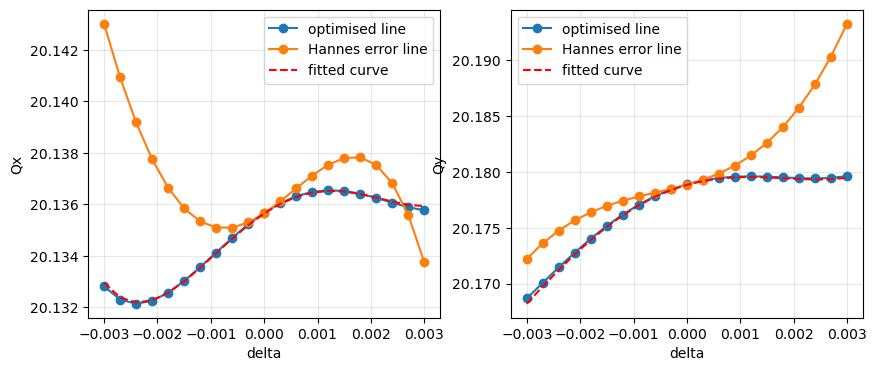

In [20]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4 , 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4 , 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

## Optimising Q3

In [21]:
opt_q3 = line.match(
    vary=[
        xt.VaryList(['b5_mba', 'b5_mbb'], step=1e-4), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx3', value=qx3, tol=(np.abs(qx3) * 0.0001), tag='qx3'),
        xt.Target(action=act_chroma, tar='qy3', value=qy3, tol=(np.abs(qy3) * 0.0001), tag='qy3'),
])

qx coeff: [ 3.70227066e+07 -9.93947215e+04 -4.85904440e+02  1.38934529e+00
  2.01356791e+01]
qy coeff: [ 2.28609940e+07  5.34336407e+04 -7.32974268e+02  1.34867345e+00
  2.01789042e+01]
qx coeff: [ 3.70227066e+07 -9.93947215e+04 -4.85904440e+02  1.38934529e+00
  2.01356791e+01]
qy coeff: [ 2.28609940e+07  5.34336407e+04 -7.32974268e+02  1.34867345e+00
  2.01789042e+01]
                                             
qx coeff: [ 3.70227066e+07 -9.93947215e+04 -4.85904440e+02  1.38934529e+00
  2.01356791e+01]
qy coeff: [ 2.28609940e+07  5.34336407e+04 -7.32974268e+02  1.34867345e+00
  2.01789042e+01]
Optimize - start penalty: 6465                              
qx coeff: [ 3.70227066e+07 -9.93947215e+04 -4.85904440e+02  1.38934529e+00
  2.01356791e+01]
qy coeff: [ 2.28609940e+07  5.34336407e+04 -7.32974268e+02  1.34867345e+00
  2.01789042e+01]
qx coeff: [ 3.70226823e+07 -9.93901471e+04 -4.85904462e+02  1.38934525e+00
  2.01356791e+01]
qy coeff: [ 2.28609879e+07  5.34311745e+04 -7.32974264e+

In [22]:
print("Decapole errors on main dipoles needed to recover third order chromaticity:")
print("b5_mba =", line.vars["b5_mba"]._get_value())
print("b5_mbb =", line.vars["b5_mbb"]._get_value())

Decapole errors on main dipoles needed to recover third order chromaticity:
b5_mba = -2.1060356265284006
b5_mbb = -0.24174124359615926


In [23]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [ 3.70281142e+07 -9.87538814e+04 -4.85905398e+02  1.38934791e+00
  2.01356791e+01]
qy coeff: [ 2.28306134e+07  5.98670445e+04 -7.32973640e+02  1.34865151e+00
  2.01789042e+01]
Q0:
targets  : 20.135651385655766 20.178849830100283
obtained : 20.13567907828043 20.17890417859345
Q1:
targets  : 1.3853870500626928 1.3404718005055556
obtained : 1.389347914447815 1.3486515071575338
Q2:
targets  : -485.37111311696805 -732.9755010775554
obtained : -485.9053981065879 -732.9736404716025
Q3:
targets  : -98753.84952493232 59867.04451836026
obtained : -98753.88137864685 59867.04453783053
Q4:
targets  : 39044666.236123264 19608320.65383154
obtained : 37028114.237458475 22830613.376919873


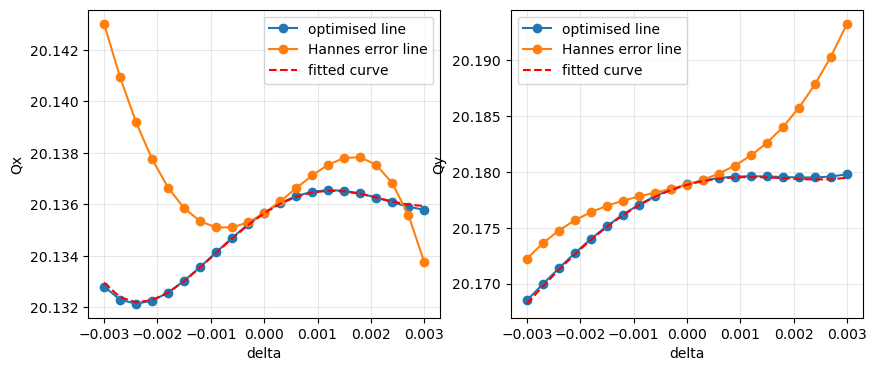

In [24]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4, 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

## Optimising Q4

In [25]:
opt_q4 = line.match(
    vary=[
        xt.VaryList(['b6_qd', 'b6_qf'], step=1e-1), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx4', value=qx4, tol=(np.abs(qx4) * 0.0001), tag='qx4'),
        xt.Target(action=act_chroma, tar='qy4', value=qy4, tol=(np.abs(qy4) * 0.0001), tag='qy4'),
    ])

qx coeff: [ 3.70281142e+07 -9.87538814e+04 -4.85905398e+02  1.38934791e+00
  2.01356791e+01]
qy coeff: [ 2.28306134e+07  5.98670445e+04 -7.32973640e+02  1.34865151e+00
  2.01789042e+01]
qx coeff: [ 3.70281142e+07 -9.87538814e+04 -4.85905398e+02  1.38934791e+00
  2.01356791e+01]
qy coeff: [ 2.28306134e+07  5.98670445e+04 -7.32973640e+02  1.34865151e+00
  2.01789042e+01]
                                             
qx coeff: [ 3.70281142e+07 -9.87538814e+04 -4.85905398e+02  1.38934791e+00
  2.01356791e+01]
qy coeff: [ 2.28306134e+07  5.98670445e+04 -7.32973640e+02  1.34865151e+00
  2.01789042e+01]
Optimize - start penalty: 3.801e+06                         
qx coeff: [ 3.70281142e+07 -9.87538814e+04 -4.85905398e+02  1.38934791e+00
  2.01356791e+01]
qy coeff: [ 2.28306134e+07  5.98670445e+04 -7.32973640e+02  1.34865151e+00
  2.01789042e+01]
qx coeff: [ 3.70282376e+07 -9.87538910e+04 -4.85905399e+02  1.38934794e+00
  2.01356791e+01]
qy coeff: [ 2.28301917e+07  5.98670602e+04 -7.32973622e+

In [26]:
print("Dodecapole errors on main quadrupoles needed to recover fourth order chromaticity:")
print("b6_qf =", line.vars["b6_qf"]._get_value())
print("b6_qd =", line.vars["b6_qd"]._get_value())

Dodecapole errors on main quadrupoles needed to recover fourth order chromaticity:
b6_qf = 1138.486379004741
b6_qd = -7963.136195554306


In [27]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [ 3.90446486e+07 -9.88861902e+04 -4.86028266e+02  1.38956223e+00
  2.01356796e+01]
qy coeff: [ 1.96083207e+07  5.99576151e+04 -7.32863236e+02  1.34852700e+00
  2.01789033e+01]
Q0:
targets  : 20.135651385655766 20.178849830100283
obtained : 20.13567955253582 20.178903324136066
Q1:
targets  : 1.3853870500626928 1.3404718005055556
obtained : 1.389562234828637 1.3485270015900883
Q2:
targets  : -485.37111311696805 -732.9755010775554
obtained : -486.02826608412335 -732.8632359156146
Q3:
targets  : -98753.84952493232 59867.04451836026
obtained : -98886.19021415622 59957.61505985766
Q4:
targets  : 39044666.236123264 19608320.65383154
obtained : 39044648.63950974 19608320.696648054


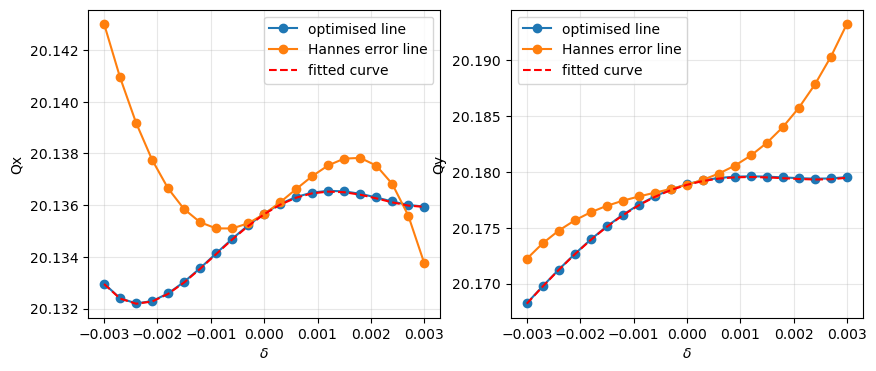

In [28]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 + qx4*delta_grid**4, 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 + qy4*delta_grid**4, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel(r"$\delta$")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

In [29]:
line.to_json("sps_with_aperture_inj_q20_beam_sagitta4_errors2.json")

In [30]:
tt = line.get_table()

In [39]:
print('MBA: ',env.element_dict['mba.10030'].knl)
print('MBB: ',env.element_dict['mbb.10070'].knl)
print('QD: ',env.element_dict['qd.10110'].knl)
print('QF: ',env.element_dict['qf.10010'].knl)

MBA:  [ 0.00000000e+00  0.00000000e+00  1.29536169e-05  0.00000000e+00
 -2.10603563e+00  0.00000000e+00]
MBB:  [ 0.00000000e+00  0.00000000e+00 -2.44799746e-05  0.00000000e+00
 -2.41741244e-01  0.00000000e+00]
QD:  [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  2.4785736e-01
  0.0000000e+00 -7.9631362e+03]
QF:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -6.56961423e-02
  0.00000000e+00  1.13848638e+03]
